In [ ]:
!pip install tensorflow numpy matplotlib scikit-learn seaborn --quiet

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    Dropout, Dense, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Add
)
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    Dropout, Dense, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Add, Concatenate   # ← add Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

print("TF version :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TF version : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# ── TRY TO DOWNLOAD TAGS CSV DIRECTLY ────────────────────────────────
import urllib.request
import os

csv_url  = ('http://www.panoradio-sdr.de/wp-content/'
            'uploads/dataset_panoradio_hf_tags.csv')
csv_path = '/content/dataset_panoradio_hf_tags.csv'

print("Attempting to download tags CSV...")
try:
    urllib.request.urlretrieve(csv_url, csv_path)
    file_size = os.path.getsize(csv_path)
    print(f"✅ Downloaded successfully: {file_size} bytes")
except Exception as e:
    print(f"❌ Download failed: {e}")
    print("Try manual download from browser")

Attempting to download tags CSV...
✅ Downloaded successfully: 3428906 bytes


In [ ]:
# ── USE CSV TO GET EXACT LABELS ───────────────────────────────────────
import pandas as pd

csv_path = '/content/dataset_panoradio_hf_tags.csv'

# Load CSV
tags = pd.read_csv(csv_path)
print("CSV shape    :", tags.shape)
print("CSV columns  :", tags.columns.tolist())
print("First 5 rows :")
print(tags.head())
print("\nLast 5 rows  :")
print(tags.tail())

CSV shape    : (172800, 3)
CSV columns  : ['idx', ' mode', ' snr']
First 5 rows :
   idx   mode   snr
0    0  morse    25
1    1  morse    25
2    2  morse    25
3    3  morse    25
4    4  morse    25

Last 5 rows  :
           idx  mode   snr
172795  172795   fax   -10
172796  172796   fax   -10
172797  172797   fax   -10
172798  172798   fax   -10
172799  172799   fax   -10


In [ ]:
# ── REBUILD LABELS FROM CSV — COMPLETE FIX ───────────────────────────
import pandas as pd
import numpy as np

# ── Step 1: Load CSV with correct column names ────────────────────────
csv_path = '/content/dataset_panoradio_hf_tags.csv'
tags     = pd.read_csv(csv_path)

# Strip spaces from column names
tags.columns = tags.columns.str.strip()
print("Columns after strip:", tags.columns.tolist())
print("Shape:", tags.shape)
print()
print("First 5 rows:")
print(tags.head())
print()
print("Unique modes:", sorted(tags['mode'].unique()))
print("Unique SNRs :", sorted(tags['snr'].unique()))

# ── Step 2: Define MODE_NAMES matching CSV mode names ─────────────────
# CSV uses: dominoex11 — we need to check exact names
csv_modes = sorted(tags['mode'].unique())
print("\nCSV mode names (exact):")
for m in csv_modes:
    print(f"    '{m}'")

Columns after strip: ['idx', 'mode', 'snr']
Shape: (172800, 3)

First 5 rows:
   idx   mode  snr
0    0  morse   25
1    1  morse   25
2    2  morse   25
3    3  morse   25
4    4  morse   25

Unique modes: ['am', 'dominoex11', 'fax', 'lsb', 'morse', 'mt63_1000', 'navtex', 'olivia16_1000', 'olivia16_500', 'olivia32_1000', 'olivia8_250', 'psk31', 'psk63', 'qpsk31', 'rtty100_850', 'rtty45_170', 'rtty50_170', 'usb']
Unique SNRs : [np.int64(-10), np.int64(-5), np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25)]

CSV mode names (exact):
    'am'
    'dominoex11'
    'fax'
    'lsb'
    'morse'
    'mt63_1000'
    'navtex'
    'olivia16_1000'
    'olivia16_500'
    'olivia32_1000'
    'olivia8_250'
    'psk31'
    'psk63'
    'qpsk31'
    'rtty100_850'
    'rtty45_170'
    'rtty50_170'
    'usb'


In [ ]:
# ── Step 3: Map CSV names to our class indices ────────────────────────

# CSV mode names exactly as they appear
# Map each to our class index
CSV_MODE_TO_IDX = {
    'morse'         : 0,
    'psk31'         : 1,
    'psk63'         : 2,
    'qpsk31'        : 3,
    'rtty45_170'    : 4,
    'rtty50_170'    : 5,
    'rtty100_850'   : 6,
    'olivia8_250'   : 7,
    'olivia16_500'  : 8,
    'olivia16_1000' : 9,
    'olivia32_1000' : 10,
    'dominoex11'    : 11,   # ← CSV uses dominoex11 not dominoex
    'mt63_1000'     : 12,
    'navtex'        : 13,
    'usb'           : 14,
    'lsb'           : 15,
    'am'            : 16,
    'fax'           : 17,
}

# Our display names (for plots and reports)
MODE_NAMES = [
    'morse', 'psk31', 'psk63', 'qpsk31',
    'rtty45_170', 'rtty50_170', 'rtty100_850',
    'olivia8_250', 'olivia16_500', 'olivia16_1000', 'olivia32_1000',
    'dominoex', 'mt63_1000', 'navtex',
    'usb', 'lsb', 'am', 'fax'
]

# ── Step 4: Build labels directly from CSV ────────────────────────────
print("Building labels from CSV...")

labels_class_csv = []
labels_snr_csv   = []
errors           = []

for i in range(len(tags)):
    mode_name = tags.iloc[i]['mode'].strip()
    snr_val   = int(tags.iloc[i]['snr'])

    if mode_name in CSV_MODE_TO_IDX:
        labels_class_csv.append(CSV_MODE_TO_IDX[mode_name])
    else:
        errors.append(f"Row {i}: unknown mode '{mode_name}'")
        labels_class_csv.append(-1)

    labels_snr_csv.append(snr_val)

labels_class = np.array(labels_class_csv, dtype=np.int32)
labels_snr   = np.array(labels_snr_csv,   dtype=np.int32)

if errors:
    print(f"⚠️  {len(errors)} unknown modes found:")
    for e in errors[:5]:
        print(f"    {e}")
else:
    print("✅ All modes mapped successfully")

print(f"\nLabels built:")
print(f"    Total samples : {len(labels_class)}")
print(f"    Unique classes: {sorted(np.unique(labels_class))}")
print(f"    Unique SNRs   : {sorted(np.unique(labels_snr))}")

# ── Step 5: Verify first and last 5 rows ──────────────────────────────
print("\nFirst 5 label assignments:")
print(f"{'Row':>6} {'CSV mode':>16} {'CSV SNR':>8} "
      f"{'Class idx':>10} {'Our name':>16}")
print("-" * 62)
for i in range(5):
    csv_mode = tags.iloc[i]['mode'].strip()
    csv_snr  = int(tags.iloc[i]['snr'])
    cls_idx  = labels_class[i]
    our_name = MODE_NAMES[cls_idx] if cls_idx >= 0 else 'ERROR'
    print(f"{i:>6} {csv_mode:>16} {csv_snr:>8} "
          f"{cls_idx:>10} {our_name:>16}")

print("\nLast 5 label assignments:")
print(f"{'Row':>6} {'CSV mode':>16} {'CSV SNR':>8} "
      f"{'Class idx':>10} {'Our name':>16}")
print("-" * 62)
for i in range(len(tags)-5, len(tags)):
    csv_mode = tags.iloc[i]['mode'].strip()
    csv_snr  = int(tags.iloc[i]['snr'])
    cls_idx  = labels_class[i]
    our_name = MODE_NAMES[cls_idx] if cls_idx >= 0 else 'ERROR'
    print(f"{i:>6} {csv_mode:>16} {csv_snr:>8} "
          f"{cls_idx:>10} {our_name:>16}")

Building labels from CSV...
✅ All modes mapped successfully

Labels built:
    Total samples : 172800
    Unique classes: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17)]
    Unique SNRs   : [np.int32(-10), np.int32(-5), np.int32(0), np.int32(5), np.int32(10), np.int32(15), np.int32(20), np.int32(25)]

First 5 label assignments:
   Row         CSV mode  CSV SNR  Class idx         Our name
--------------------------------------------------------------
     0            morse       25          0            morse
     1            morse       25          0            morse
     2            morse       25          0            morse
     3            morse       25          0            morse
     4            morse       25          0            morse

Last 5 label assignments:
   Row         CSV 

In [ ]:
# ── All constants defined AFTER CSV labels ────────────────────────────
NUM_CLASSES = 18
IQ_LENGTH   = 2048

# SNR values directly from CSV — ground truth
SNR_VALUES = sorted(np.unique(labels_snr).tolist())

# Display names for plots and reports
MODE_NAMES = [
    'morse', 'psk31', 'psk63', 'qpsk31',
    'rtty45_170', 'rtty50_170', 'rtty100_850',
    'olivia8_250', 'olivia16_500', 'olivia16_1000', 'olivia32_1000',
    'dominoex', 'mt63_1000', 'navtex',
    'usb', 'lsb', 'am', 'fax'
]

print(f"NUM_CLASSES : {NUM_CLASSES}")
print(f"IQ_LENGTH   : {IQ_LENGTH}")
print(f"SNR_VALUES  : {SNR_VALUES}")
print(f"MODE_NAMES  : {MODE_NAMES}")

# Confirm labels match expected counts
print("\nSamples per class:")
for cls in range(NUM_CLASSES):
    count = np.sum(labels_class == cls)
    print(f"  {MODE_NAMES[cls]:>20} : {count}")

print("\nSamples per SNR:")
for snr in SNR_VALUES:
    count = np.sum(labels_snr == snr)
    print(f"  SNR {snr:>4} dB : {count}")

NUM_CLASSES : 18
IQ_LENGTH   : 2048
SNR_VALUES  : [-10, -5, 0, 5, 10, 15, 20, 25]
MODE_NAMES  : ['morse', 'psk31', 'psk63', 'qpsk31', 'rtty45_170', 'rtty50_170', 'rtty100_850', 'olivia8_250', 'olivia16_500', 'olivia16_1000', 'olivia32_1000', 'dominoex', 'mt63_1000', 'navtex', 'usb', 'lsb', 'am', 'fax']

Samples per class:
                 morse : 9600
                 psk31 : 9600
                 psk63 : 9600
                qpsk31 : 9600
            rtty45_170 : 9600
            rtty50_170 : 9600
           rtty100_850 : 9600
           olivia8_250 : 9600
          olivia16_500 : 9600
         olivia16_1000 : 9600
         olivia32_1000 : 9600
              dominoex : 9600
             mt63_1000 : 9600
                navtex : 9600
                   usb : 9600
                   lsb : 9600
                    am : 9600
                   fax : 9600

Samples per SNR:
  SNR  -10 dB : 21600
  SNR   -5 dB : 21600
  SNR    0 dB : 21600
  SNR    5 dB : 21600
  SNR   10 dB : 21600
  SNR   

In [ ]:
# ── UPDATE THIS PATH ──────────────────────────────────────────────────
DATASET_PATH = '/content/gdrive/MyDrive/panoradio_dataset/dataset_panoradio_hf.npy'

print("Loading dataset...")
t0       = time.time()
raw_data = np.load(DATASET_PATH)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Shape : {raw_data.shape}")
print(f"Dtype : {raw_data.dtype}")

assert raw_data.shape[0] == 172800, \
    f"Expected 172800 rows, got {raw_data.shape[0]}"
print("✅ Row count correct")

Loading dataset...
Done in 24.4s
Shape : (172800, 2048)
Dtype : complex128
✅ Row count correct


In [ ]:
print("Converting complex → [I, Q] float32...")
t0 = time.time()

I = raw_data.real.astype(np.float32)
Q = raw_data.imag.astype(np.float32)

power = np.sqrt(np.mean(I**2 + Q**2, axis=1, keepdims=True))
power = np.where(power < 1e-10, 1.0, power)
I    /= power
Q    /= power

X = np.stack([I, Q], axis=-1)   # (172800, 2048, 2)

print(f"Done in {time.time()-t0:.1f}s")
print(f"X shape : {X.shape}")
print(f"X dtype : {X.dtype}")

del raw_data, I, Q
import gc; gc.collect()
print("Raw data freed.")

Converting complex → [I, Q] float32...
Done in 11.0s
X shape : (172800, 2048, 2)
X dtype : float32
Raw data freed.


In [ ]:
y = to_categorical(labels_class, num_classes=NUM_CLASSES)

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = \
    train_test_split(
        X, y, labels_snr,
        test_size=0.30,
        random_state=SEED,
        stratify=labels_class
    )

y_temp_idx = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test, snr_val, snr_test = \
    train_test_split(
        X_temp, y_temp, snr_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=y_temp_idx
    )

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# Verify distributions
print("\nSNR distribution in test set:")
snr_u, snr_c = np.unique(snr_test, return_counts=True)
expected      = int(len(snr_test) / 8)
for snr, cnt in zip(snr_u, snr_c):
    status = "✅" if abs(cnt - expected) < 100 else "⚠️"
    print(f"  SNR {snr:>4} dB : {cnt}  {status}")

print("\nClass distribution in test set:")
cls_u, cls_c = np.unique(np.argmax(y_test, axis=1),
                          return_counts=True)
for cls, cnt in zip(cls_u, cls_c):
    status = "✅" if cnt == 1440 else "⚠️"
    print(f"  {MODE_NAMES[cls]:>20} : {cnt}  {status}")

Train : (120960, 2048, 2)
Val   : (25920, 2048, 2)
Test  : (25920, 2048, 2)

SNR distribution in test set:
  SNR  -10 dB : 3262  ✅
  SNR   -5 dB : 3228  ✅
  SNR    0 dB : 3210  ✅
  SNR    5 dB : 3217  ✅
  SNR   10 dB : 3159  ✅
  SNR   15 dB : 3267  ✅
  SNR   20 dB : 3247  ✅
  SNR   25 dB : 3330  ✅

Class distribution in test set:
                 morse : 1440  ✅
                 psk31 : 1440  ✅
                 psk63 : 1440  ✅
                qpsk31 : 1440  ✅
            rtty45_170 : 1440  ✅
            rtty50_170 : 1440  ✅
           rtty100_850 : 1440  ✅
           olivia8_250 : 1440  ✅
          olivia16_500 : 1440  ✅
         olivia16_1000 : 1440  ✅
         olivia32_1000 : 1440  ✅
              dominoex : 1440  ✅
             mt63_1000 : 1440  ✅
                navtex : 1440  ✅
                   usb : 1440  ✅
                   lsb : 1440  ✅
                    am : 1440  ✅
                   fax : 1440  ✅


In [ ]:
class AttentionPooling(tf.keras.layers.Layer):
    """
    Learnable attention pooling.
    Learns which timesteps matter most
    and weights them accordingly.
    Better than mean pooling for RF signals.
    """
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.attention_dense = Dense(d_model, activation='tanh')
        self.attention_score = Dense(1)

    def call(self, x):
        e     = self.attention_dense(x)
        e     = self.attention_score(e)
        alpha = tf.nn.softmax(e, axis=1)
        out   = tf.reduce_sum(alpha * x, axis=1)
        return out

print("AttentionPooling defined.")

AttentionPooling defined.


In [ ]:
def transformer_encoder_block(x, d_model, num_heads, ff_dim,
                               dropout_rate=0.2, name_prefix=''):
    """
    Single Transformer encoder block:
        Multi-Head Self-Attention → Add & LayerNorm
        Feed-Forward Network      → Add & LayerNorm
    """
    # Multi-Head Self-Attention
    attn_out = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate,
        name=f'{name_prefix}_mha'
    )(x, x)
    attn_out = Dropout(dropout_rate,
                       name=f'{name_prefix}_drop1')(attn_out)
    x        = Add(    name=f'{name_prefix}_add1')([x, attn_out])
    x        = LayerNormalization(epsilon=1e-6,
                                  name=f'{name_prefix}_ln1')(x)

    # Feed-Forward Network
    ffn = Dense(ff_dim, activation='relu',
                name=f'{name_prefix}_ffn1')(x)
    ffn = Dropout(dropout_rate,
                  name=f'{name_prefix}_drop2')(ffn)
    ffn = Dense(d_model,
                name=f'{name_prefix}_ffn2')(ffn)
    ffn = Dropout(dropout_rate,
                  name=f'{name_prefix}_drop3')(ffn)
    x   = Add(    name=f'{name_prefix}_add2')([x, ffn])
    x   = LayerNormalization(epsilon=1e-6,
                              name=f'{name_prefix}_ln2')(x)
    return x

print("Transformer encoder block defined.")

Transformer encoder block defined.


In [ ]:
# ── Sinusoidal positional encoding ───────────────────────────────────
# Same formula as Vaswani et al. (2017) "Attention is All You Need"
# This is identical to your DDP Stage 1 positional encoding

def get_positional_encoding(seq_len, d_model):
    """
    Sinusoidal positional encoding.
    Vaswani et al. (2017) Attention is All You Need.
    Returns (1, seq_len, d_model).
    """
    positions = np.arange(seq_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / np.power(
        10000, (2 * (dims // 2)) / np.float32(d_model)
    )
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

print("Positional encoding defined.")

Positional encoding defined.


In [ ]:
def build_cnn_transformer_model(input_length=2048, n_channels=2,
                                 n_classes=18, d_model=128,
                                 num_heads=8, ff_dim=256,
                                 num_transformer_blocks=3,
                                 dropout_rate=0.2):
    """
    CNN-Transformer hybrid for HF radio signal classification.

    Architecture:
        CNN blocks    : compress (2048, 2) → (64, 256)
        Linear proj   : project  (64, 256) → (64, d_model=128)
        Pos encoding  : add positional info to (64, 128)
        Transformer   : N encoder blocks on (64, 128)
        Attn Pooling  : (64, 128) → (128,)
        Side branch   : envelope periodicity features → (32,)
        Fusion        : (128+32,) → Dense → (18,)
    """
    inp = Input(shape=(input_length, n_channels), name='iq_input')

    # ── CNN feature extraction ────────────────────────────────────────
    # Block 1: 2048 → 512
    x = Conv1D(64,  kernel_size=11, padding='same',
               activation='relu', name='conv1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = MaxPooling1D(pool_size=4, name='pool1')(x)
    x = Dropout(dropout_rate * 0.5, name='drop_cnn1')(x)

    # Block 2: 512 → 128
    x = Conv1D(128, kernel_size=7, padding='same',
               activation='relu', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = MaxPooling1D(pool_size=4, name='pool2')(x)
    x = Dropout(dropout_rate * 0.5, name='drop_cnn2')(x)

    # Block 3: 128 → 64
    x = Conv1D(256, kernel_size=5, padding='same',
               activation='relu', name='conv3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = MaxPooling1D(pool_size=2, name='pool3')(x)
    x = Dropout(dropout_rate * 0.5, name='drop_cnn3')(x)

    # ── Linear projection ─────────────────────────────────────────────
    x = Dense(d_model, name='linear_proj')(x)       # (batch, 64, 128)

    # ── Positional encoding ───────────────────────────────────────────
    seq_len = x.shape[1]                            # 64
    pos_enc = get_positional_encoding(seq_len, d_model)
    x = x + pos_enc

    # ── Transformer blocks ────────────────────────────────────────────
    for i in range(num_transformer_blocks):
        x = transformer_encoder_block(
            x,
            d_model=d_model,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate,
            name_prefix=f'transformer_block{i+1}'
        )

    # ── Attention Pooling ─────────────────────────────────────────────
    main_features = AttentionPooling(d_model, name='attn_pool')(x)
    # (batch, 128)

    # ── SIDE BRANCH — Periodicity / Baud Rate Detector ───────────────
    I_chan   = inp[:, :, 0:1]
    Q_chan   = inp[:, :, 1:2]

    # ✅ keras.ops instead of tf ops — safe on KerasTensors
    envelope = tf.keras.ops.sqrt(
        tf.keras.ops.square(I_chan) + tf.keras.ops.square(Q_chan) + 1e-8
    )
    # (batch, 2048, 1)

    env_pooled = MaxPooling1D(pool_size=4, name='env_pool1')(envelope)
    # (batch, 512, 1)

    p = Conv1D(32, kernel_size=15, padding='same',
               activation='relu', name='periodicity_conv')(env_pooled)
    p = BatchNormalization(name='periodicity_bn')(p)
    p = MaxPooling1D(pool_size=4, name='periodicity_pool')(p)
    # (batch, 128, 32)

    periodicity_features = GlobalAveragePooling1D(name='periodicity_gap')(p)
    # (batch, 32)

    # ── FUSION ────────────────────────────────────────────────────────
    fused = Concatenate(name='fuse_features')([main_features, periodicity_features])
    # (batch, 160)

    fused = Dense(128, activation='relu', name='fc1')(fused)
    fused = Dropout(dropout_rate, name='drop_fc')(fused)
    out   = Dense(n_classes, activation='softmax', name='output')(fused)

    model = Model(inputs=inp, outputs=out, name='CNN_Transformer_V2')
    return model


# ── Build ─────────────────────────────────────────────────────────────
transformer_model = build_cnn_transformer_model(
    input_length=IQ_LENGTH,
    n_channels=2,
    n_classes=NUM_CLASSES,
    d_model=128,
    num_heads=8,
    ff_dim=256,
    num_transformer_blocks=3,
    dropout_rate=0.2
)

transformer_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

transformer_model.summary()

Model: "CNN_Transformer_V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ iq_input            │ (None, 2048, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 2048, 64)  │      1,472 │ iq_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 2048, 64)  │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 512, 64)   │          0 │ bn1[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_cnn1 (Dropout) │ (None, 512, 64)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 512, 128)  │     57,472 │ drop_cnn1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 512, 128)  │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 128, 128)  │          0 │ bn2[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_cnn2 (Dropout) │ (None, 128, 128)  │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 128, 256)  │    164,096 │ drop_cnn2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 128, 256)  │      1,024 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 64, 256)   │          0 │ bn3[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_cnn3 (Dropout) │ (None, 64, 256)   │          0 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ linear_proj (Dense) │ (None, 64, 128)   │     32,896 │ drop_cnn3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 128)   │          0 │ linear_proj[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block1… │ (None, 64, 128)   │     66,048 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block1… │ (None, 64, 128)   │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block1… │ (None, 64, 128)   │          0 │ add[0][0],        │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block1… │ (None, 64, 128)   │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 695,379 (2.65 MB)

 Trainable params: 694,419 (2.65 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Give RTTY45 and RTTY50 slightly higher loss weight
# so the model pays more attention to getting them right

class_weights = {i: 1.0 for i in range(NUM_CLASSES)}
class_weights[4] = 1.5   # rtty45_170
class_weights[5] = 1.5   # rtty50_170

# Convert to sample weights for fit()
sample_weights_train = np.array(
    [class_weights[c] for c in np.argmax(y_train, axis=1)]
)

EPOCHS     = 80
BATCH_SIZE = 64
PATIENCE   = 15

cb_list = [
    ModelCheckpoint(
        'best_transformer_panoradio.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

print("Training CNN-Transformer ...")
t0 = time.time()

history_transformer = transformer_model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,   # ← weighted RTTY classes
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=cb_list,
    verbose=1
)

print(f"\nTraining done in {(time.time()-t0)/60:.1f} min")

Training CNN-Transformer ...
Epoch 1/80
1889/1890 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5241 - loss: 1.6336
Epoch 1: val_accuracy improved from None to 0.78615, saving model to best_transformer_panoradio.keras

Epoch 1: finished saving model to best_transformer_panoradio.keras
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 111s 42ms/step - accuracy: 0.6616 - loss: 1.2322 - val_accuracy: 0.7861 - val_loss: 0.8411 - learning_rate: 5.0000e-04
Epoch 2/80
1889/1890 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7995 - loss: 0.8671
Epoch 2: val_accuracy improved from 0.78615 to 0.82905, saving model to best_transformer_panoradio.keras

Epoch 2: finished saving model to best_transformer_panoradio.keras
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 78s 41ms/step - accuracy: 0.8068 - loss: 0.8457 - val_accuracy: 0.8291 - val_loss: 0.7277 - learning_rate: 5.0000e-04
Epoch 3/80
1889/1890 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8258 - loss: 0.7919
Epoch 3: val_accuracy improved from 0.82905 to 0.84043, saving

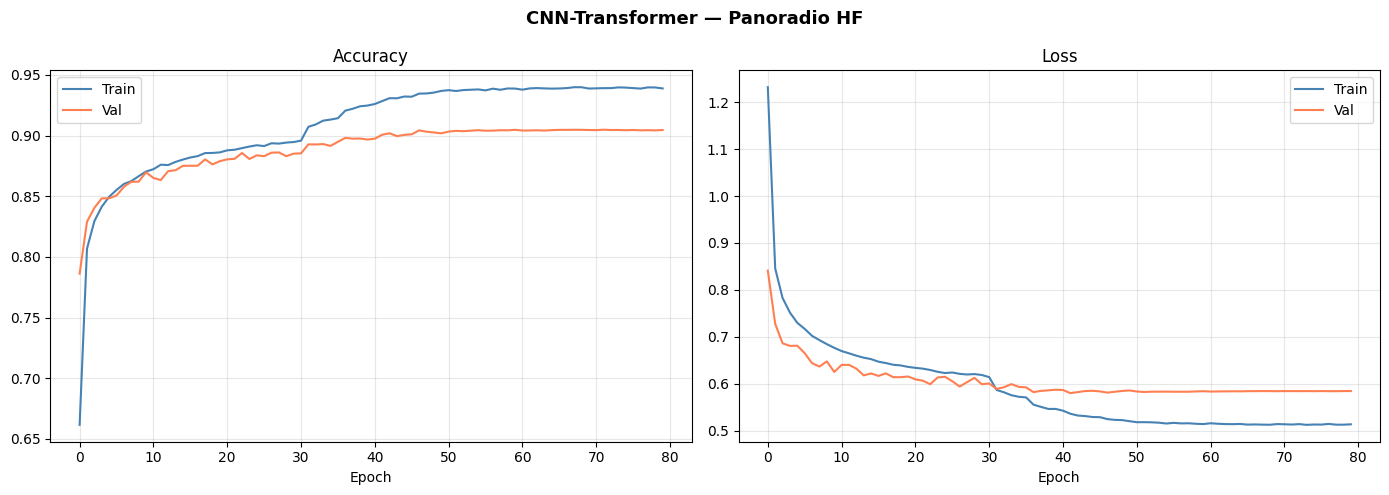

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_transformer.history['accuracy'],
             label='Train', color='steelblue')
axes[0].plot(history_transformer.history['val_accuracy'],
             label='Val',   color='coral')
axes[0].set_title('Accuracy');  axes[0].set_xlabel('Epoch')
axes[0].legend();               axes[0].grid(True, alpha=0.3)

axes[1].plot(history_transformer.history['loss'],
             label='Train', color='steelblue')
axes[1].plot(history_transformer.history['val_loss'],
             label='Val',   color='coral')
axes[1].set_title('Loss');      axes[1].set_xlabel('Epoch')
axes[1].legend();               axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN-Transformer — Panoradio HF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%\n")

y_pred = np.argmax(model.predict(X_test, batch_size=BATCH_SIZE, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=MODE_NAMES))

Test Loss     : 0.2524
Test Accuracy : 92.19%

               precision    recall  f1-score   support

        morse       0.94      0.97      0.95      1440
        psk31       0.79      0.88      0.83      1440
        psk63       0.91      0.84      0.88      1440
       qpsk31       0.77      0.77      0.77      1440
   rtty45_170       0.85      0.90      0.88      1440
   rtty50_170       0.89      0.84      0.87      1440
  rtty100_850       0.99      0.99      0.99      1440
  olivia8_250       0.93      0.95      0.94      1440
 olivia16_500       0.96      0.95      0.95      1440
olivia16_1000       0.99      0.95      0.97      1440
olivia32_1000       0.95      0.96      0.95      1440
     dominoex       0.92      0.95      0.93      1440
    mt63_1000       0.99      0.97      0.98      1440
       navtex       0.99      0.96      0.97      1440
          usb       0.97      0.98      0.97      1440
          lsb       0.96      0.97      0.96      1440
           am    

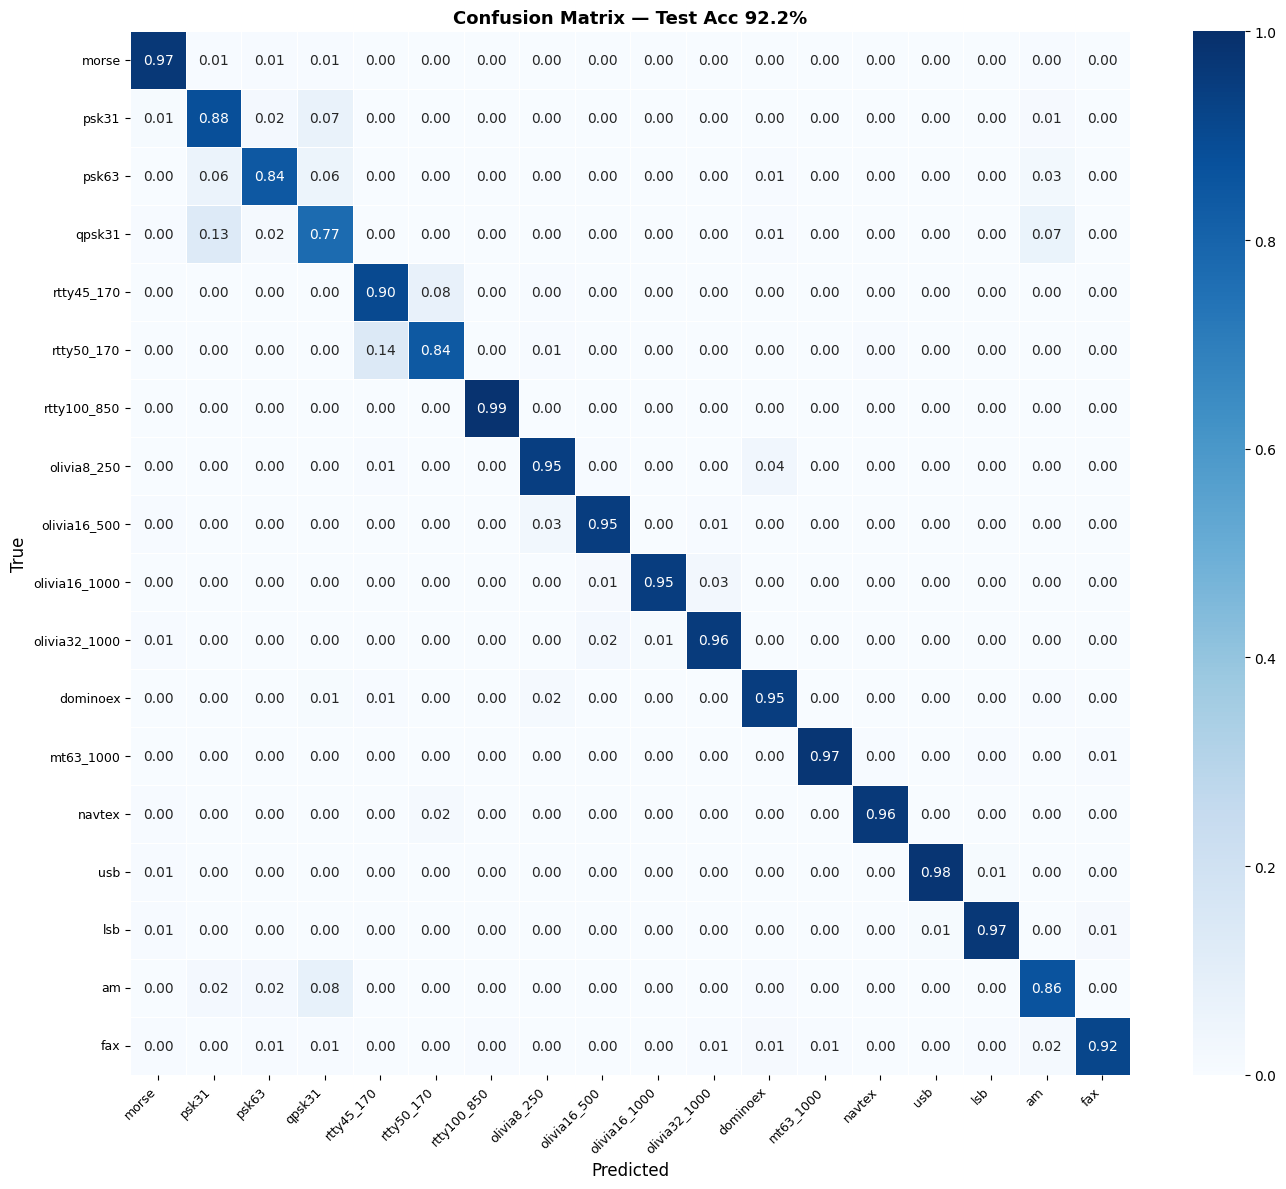

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=MODE_NAMES, yticklabels=MODE_NAMES,
            vmin=0, vmax=1, linewidths=0.5)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True',      fontsize=12)
plt.title(f'Confusion Matrix — Test Acc {test_acc*100:.1f}%', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.show()

SNR  -10 dB  →  72.0%
SNR   -5 dB  →  87.6%
SNR   +0 dB  →  92.5%
SNR   +5 dB  →  93.8%
SNR  +10 dB  →  94.8%
SNR  +15 dB  →  95.4%
SNR  +20 dB  →  95.2%
SNR  +25 dB  →  95.9%


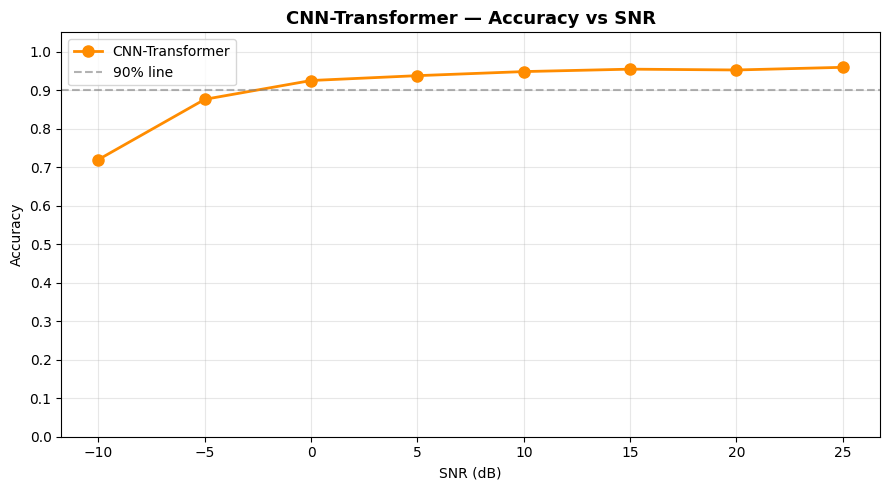

In [ ]:
snr_acc_transformer = {}
for snr in sorted(SNR_VALUES):
    idx   = np.where(snr_test == snr)[0]
    y_hat = transformer_model.predict(
        X_test[idx], batch_size=BATCH_SIZE, verbose=0
    )
    acc   = np.mean(
        np.argmax(y_hat, axis=1) == np.argmax(y_test[idx], axis=1)
    )
    snr_acc_transformer[snr] = acc
    print(f"SNR {snr:+4d} dB  →  {acc*100:.1f}%")

plt.figure(figsize=(9, 5))
plt.plot(list(snr_acc_transformer.keys()),
         list(snr_acc_transformer.values()),
         'o-', color='darkorange', linewidth=2,
         markersize=8, label='CNN-Transformer')
plt.axhline(0.9, color='gray', linestyle='--',
            alpha=0.6, label='90% line')
plt.xlabel('SNR (dB)');  plt.ylabel('Accuracy')
plt.title('CNN-Transformer — Accuracy vs SNR', fontsize=13, fontweight='bold')
plt.xticks(sorted(SNR_VALUES))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.05);  plt.grid(True, alpha=0.3);  plt.legend()
plt.tight_layout()
plt.show()